# Exploratory Data Analysis (EDA) — Kyivan Dataset

Этот ноутбук предназначен для анализа финального собранного датасета исторических славянских текстов.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import numpy as np
from collections import Counter

# Настройки графиков
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Загрузка данных
Читаем `final_dataset.jsonl` в `pandas.DataFrame`.


In [2]:
data = []
with open('../data/final_dataset.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)
df['text_len_chars'] = df['text'].apply(len)
df['text_len_words'] = df['text'].apply(lambda x: len(x.split()))

print(f"Всего документов: {len(df)}")
display(df.head())


Всего документов: 5181


,doc_id,text,macro_dialect,date_interval,date_target,date_number,category,original_dialect,original,target,masked,number,date,category_mapped,region,genre,text_len_chars,text_len_words
0,gramoty_akty_14_16/28_akty_XIV_XVI,"Се яз, Миня, чернец игуменов Никонов, Сергиева...",OES,"[1300, 1700]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,unknown,Middle Russian,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,187,32
1,NaN,и позвале насъ · господине на комелъ и пошли є...,NW,"[1280, 1300]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,письма,NaN,и позвале насъ · господине на комелъ и пошли є...,и позвале насъ · господине на комелъ и пошли є...,и позвале насъ · господине на комелъ и пошли є...,929,1280‒1300 (с вероятным смещением вперёд),letters,Новгород,частное письмо,110,20
2,NaN,[GAP] го слово площ[GAP] ги аще на не азо ги н...,NW,"[1240, 1260]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.476...",NaN,церковные тексты,NaN,[GAP] го слово пло[щ][GAP] г[и] аще на не азо ...,[GAP] го слово площ[GAP] ги аще на не азо ги н...,[GAP] го слово пло[GAP] г[GAP] аще на не азо г...,331,1240‒1260 (с вероятным смещением вперёд),religious,Новгород,литургический текст,57,13
3,nkrya_scraped_343,Гсдрь мои млстивои Степанъ Григорьевичь здравъ...,OES,"[1651, 1700]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,DAILY,starorus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,204,33
4,nkrya_scraped_1516,"Список · Се аз , князь великий Василей Василье...",OES,"[1400, 1500]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",NaN,LEGAL,starorus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,237,38


## 2. Распределение Макро-Диалектов (По документам и по объему слов)
Количество документов не всегда честно отражает баланс классов, так как летописи (OES) огромные, а берестяные грамоты (NW) очень короткие. Давайте посмотрим на распределение текстов как по количеству документов, так и по общему количеству слов.


C:\Users\Alex\AppData\Local\Temp\ipykernel_70116\4157983075.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=words_per_dialect.index, y=words_per_dialect.values, ax=axes[1], palette='viridis')


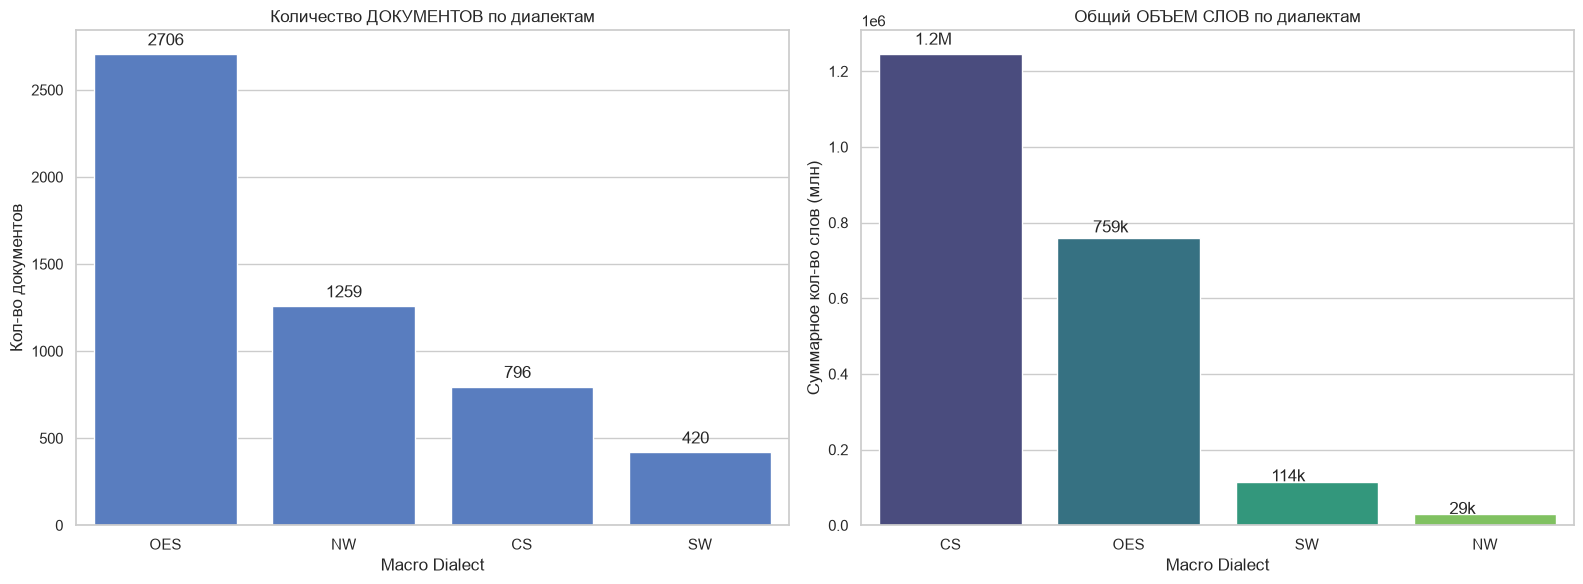

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: По количеству документов
sns.countplot(data=df, x='macro_dialect', order=df['macro_dialect'].value_counts().index, ax=axes[0])
axes[0].set_title('Количество ДОКУМЕНТОВ по диалектам')
axes[0].set_xlabel('Macro Dialect')
axes[0].set_ylabel('Кол-во документов')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + 0.3, p.get_height() + 50))

# График 2: По суммарному количеству слов
words_per_dialect = df.groupby('macro_dialect')['text_len_words'].sum().sort_values(ascending=False)
sns.barplot(x=words_per_dialect.index, y=words_per_dialect.values, ax=axes[1], palette='viridis')
axes[1].set_title('Общий ОБЪЕМ СЛОВ по диалектам')
axes[1].set_xlabel('Macro Dialect')
axes[1].set_ylabel('Суммарное кол-во слов (млн)')
# Форматируем подписи в миллионах или тысячах
for p in axes[1].patches:
    val = p.get_height()
    if val > 1_000_000:
        label = f'{val/1_000_000:.1f}M'
    else:
        label = f'{val/1000:.0f}k'
    axes[1].annotate(label, (p.get_x() + 0.2, val + val*0.02))

plt.tight_layout()
plt.show()


## 3. Распределение по времени (По документам и по объему слов)
Так же как и с диалектами, посмотрим распределение исторического времени не только в штуках (документах), но и в реальном объеме (словах). Для этого мы умножим вектор вероятностей каждой даты на объем этого документа.


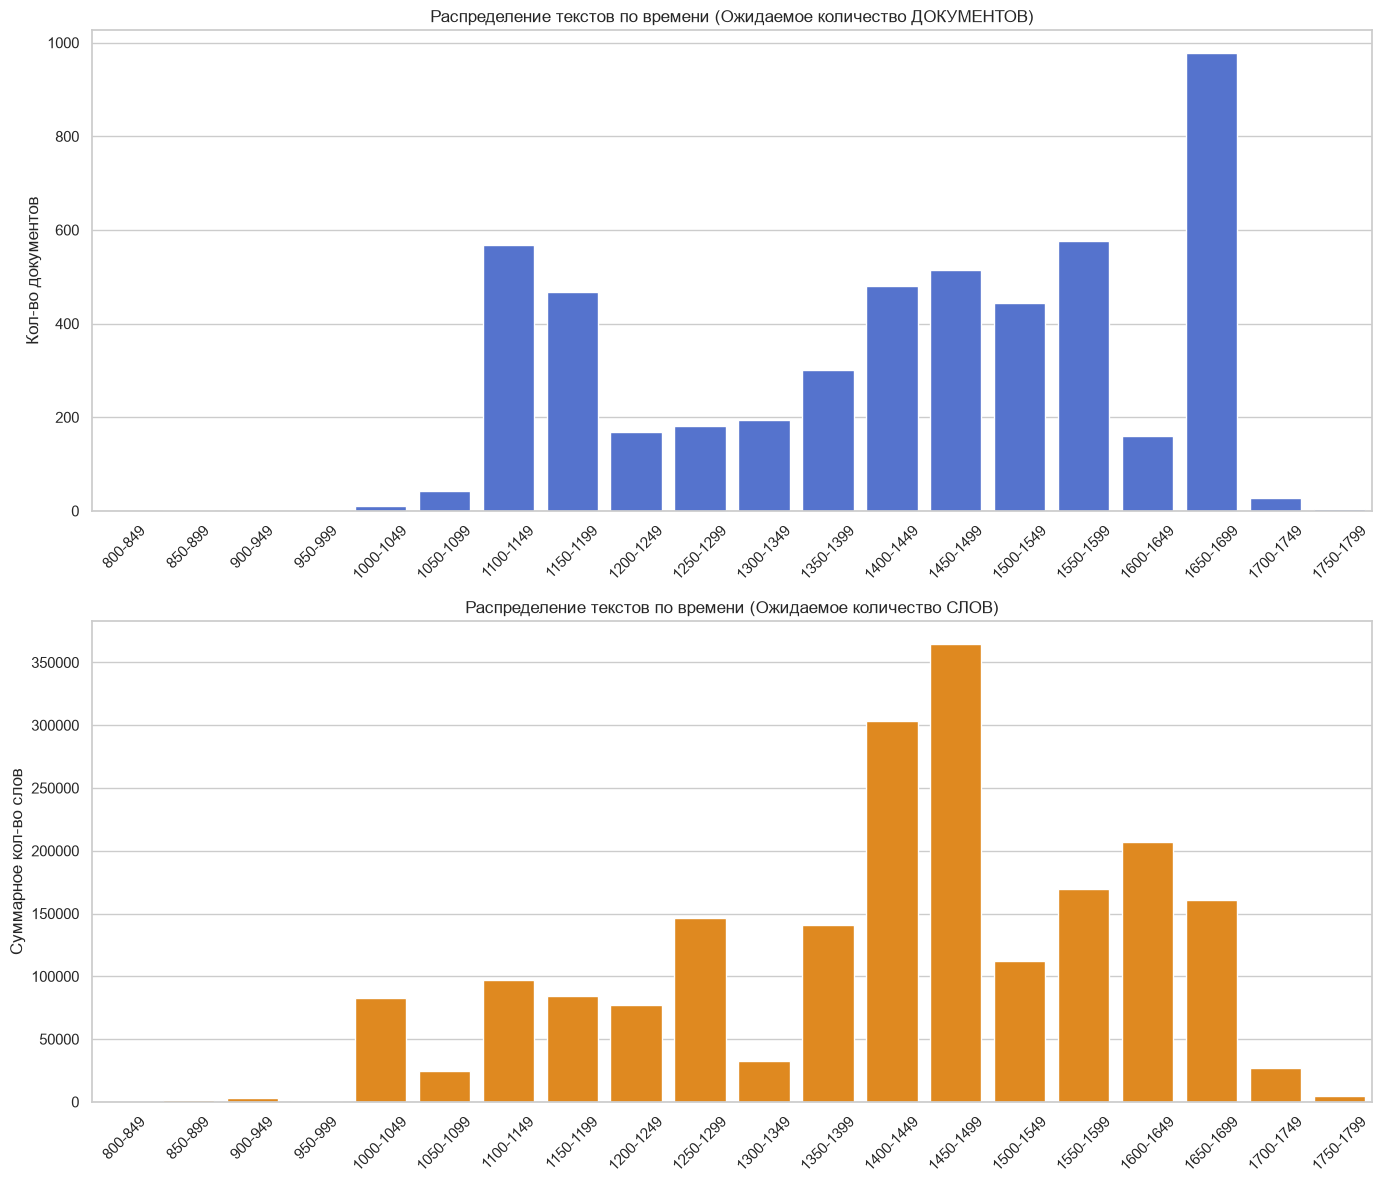

In [4]:
# Вектора по документам (Сумма вероятностей)
all_targets = np.array(df['date_target'].tolist())
sum_docs = all_targets.sum(axis=0)

# Вектора по словам (Умножаем вектор вероятностей на длину текста в словах)
word_lengths = df['text_len_words'].values.reshape(-1, 1)
weighted_targets = all_targets * word_lengths
sum_words = weighted_targets.sum(axis=0)

# Подготовим подписи для корзин
start_year = 800
bucket_size = 50
labels = [f"{start_year + i*bucket_size}-{start_year + (i+1)*bucket_size - 1}" for i in range(20)]

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# График 1: По документам
sns.barplot(x=labels, y=sum_docs, ax=axes[0], color='royalblue')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Распределение текстов по времени (Ожидаемое количество ДОКУМЕНТОВ)')
axes[0].set_ylabel('Кол-во документов')

# График 2: По словам
sns.barplot(x=labels, y=sum_words, ax=axes[1], color='darkorange')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Распределение текстов по времени (Ожидаемое количество СЛОВ)')
axes[1].set_ylabel('Суммарное кол-во слов')

plt.tight_layout()
plt.show()


## 4. Длина текстов
Проанализируем среднюю длину текста в зависимости от диалекта/источника.


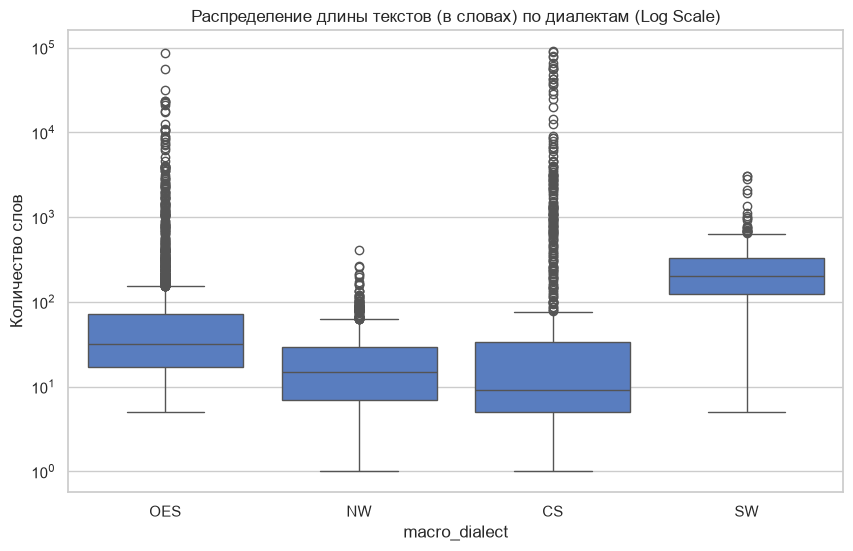

In [5]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='macro_dialect', y='text_len_words')
plt.yscale('log')
plt.title('Распределение длины текстов (в словах) по диалектам (Log Scale)')
plt.ylabel('Количество слов')
plt.show()


## 5. Анализ символов (Специфика исторической орфографии)
Посмотрим на самые частые и самые редкие символы в нашем корпусе, чтобы убедиться, что мы сохранили «юсы» и «омеги».


In [6]:
all_text = " ".join(df['text'].tolist())
char_counts = Counter(all_text)

# Исключаем пробелы и стандартные знаки препинания для наглядности
import string
exclude = set(string.ascii_letters + string.punctuation + string.digits + " 

")
filtered_chars = {k: v for k, v in char_counts.items() if k not in exclude}

top_chars = dict(Counter(filtered_chars).most_common(20))
bottom_chars = dict(Counter(filtered_chars).most_common()[-30:])

print("--- ТОП 20 кириллических символов ---")
print(top_chars)

print("\n--- Редкие символы (Юсы, Омеги, диакритика) ---")
print(bottom_chars)


SyntaxError: unterminated string literal (detected at line 6) (339475166.py, line 6)